# FIN 7053: Algorithmic Trading — Final Project
## Long-Only Equity Strategy: Mean Reversion and Momentum Composite Signal

**Universe:** S&P 500 Large-Cap (60 stocks, 2015–2026)  
**Signals:** 5-day short-term reversal (40%) and 12-1 month momentum (60%)  
**Execution:** Monthly rebalance · Equal-weight · Long-only · 15 bps one-way TC

In [1]:
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")
import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import yfinance as yf
from scipy import stats

print(" All imports loaded successfully")

 All imports loaded successfully


In [2]:
# Configuration Setup

# Universe
# Large-cap S&P 500 names across 11 sectors; extend to full 500 for production
TICKERS = [
    "AAPL", "MSFT", "GOOGL", "AMZN", "META", "NVDA", "JPM",  "JNJ",  "V",   "PG",
    "HD",   "MA",   "UNH",   "BAC",  "XOM",  "ABBV", "PFE",  "AVGO", "CVX", "LLY",
    "COST", "TMO",  "MRK",   "WMT",  "DIS",  "CSCO", "ABT",  "ACN",  "VZ",  "ADBE",
    "CRM",  "NFLX", "DHR",   "TXN",  "NEE",  "INTC", "MDT",  "PM",   "BMY", "AMGN",
    "HON",  "UPS",  "IBM",   "LIN",  "RTX",  "QCOM", "LOW",  "SBUX", "CAT", "GE",
    "GS",   "MS",   "BLK",   "SPGI", "MMM",  "T",    "F",    "GM",   "USB", "AXP",
]

BENCHMARK_TICKER = "SPY"          # S&P 500 ETF used for alpha/beta/IR
START_DATE       = "2015-01-01"
END_DATE         = datetime.date.today().strftime("%Y-%m-%d")

# Signal parameters
REV_WINDOW      = 5    # days: short-term reversal look-back
MOM_SHORT_SKIP  = 21   # days: skip most recent month (avoid reversal contamination)
MOM_LONG_WINDOW = 252  # days: 12-month momentum look-back
COMPOSITE_W_REV = 0.40 # weight on reversal in composite score
COMPOSITE_W_MOM = 0.60 # weight on momentum in composite score

# Portfolio construction
DECILE     = 0.10  # top-10% composite score; LONG portfolio
MIN_STOCKS = 5     # minimum stocks required to form a portfolio

# Transaction costs (implementation shortfall model)
BID_ASK_SPREAD_PCT = 0.0010   # 10 bps one-way
MARKET_IMPACT_PCT  = 0.0005   # 5  bps one-way
COST_PER_TRADE     = BID_ASK_SPREAD_PCT + MARKET_IMPACT_PCT  # 15 bps total

# Walk-forward parameters
TRAIN_MONTHS = 36
TEST_MONTHS  = 6

# Plot styling
plt.rcParams.update({
    "figure.facecolor": "#0f1117", "axes.facecolor": "#0f1117",
    "axes.edgecolor":  "#444",     "axes.labelcolor": "#ccc",
    "xtick.color":     "#ccc",     "ytick.color":     "#ccc",
    "text.color":      "#eee",     "grid.color":      "#333",
    "grid.linestyle":  "--",       "grid.alpha":       0.5,
    "legend.facecolor":"#1e1e2e",  "legend.edgecolor": "#555",
    "lines.linewidth":  1.8,       "font.size":        11,
})
ACCENT = "#00c8ff"
GOLD   = "#ffd700"
RED    = "#ff4d4d"
GREEN  = "#00e676"
GRAY   = "#888888"

def pct_fmt(x, _):
    return f"{x:.0%}"

print(" Configuration set")
print(f"  Universe       : {len(TICKERS)} tickers")
print(f"  Benchmark      : {BENCHMARK_TICKER}")
print(f"  Date range     : {START_DATE}  →  {END_DATE}")
print(f"  Signal weights : Rev {COMPOSITE_W_REV:.0%} | Mom {COMPOSITE_W_MOM:.0%}")
print(f"  TC (one-way)   : {COST_PER_TRADE:.0%} ({COST_PER_TRADE*10000:.0f} bps)")

 Configuration set
  Universe       : 60 tickers
  Benchmark      : SPY
  Date range     : 2015-01-01  →  2026-04-22
  Signal weights : Rev 40% | Mom 60%
  TC (one-way)   : 0% (15 bps)


**1. Data Download**

In [3]:
def download_prices(tickers, start, end):
    """
    Download adjusted close prices from Yahoo Finance via yfinance.

    Uses auto_adjust=True so prices are split- and dividend-adjusted.
    Tickers with >20% missing observations are dropped.

    Survivorship-bias note:
        yfinance only returns currently listed tickers. For a fully bias-free
        backtest, replace with CRSP point-in-time data (includes delistings).
        The walk-forward OOS and BH-FDR correction partially mitigate this.
    """
    print(f"Downloading {len(tickers)} tickers  [{start} → {end}]")
    raw = yf.download(tickers, start=start, end=end,
                      auto_adjust=True, progress=True, threads=True)["Close"]

    if isinstance(raw, pd.Series):
        raw = raw.to_frame(tickers[0])

    missing_pct = raw.isna().mean()
    keep        = missing_pct[missing_pct < 0.20].index.tolist()
    dropped     = sorted(set(tickers) - set(keep))
    if dropped:
        print(f"  ⚠  Dropped {len(dropped)} tickers (>20% missing): {dropped}")

    prices = raw[keep].ffill()
    prices = prices.dropna(axis=1, thresh=int(0.80 * len(prices))).dropna(how="all")

    print(f" Universe   : {prices.shape[1]} stocks | {prices.shape[0]} trading days")
    print(f" Date range : {prices.index[0].date()}  →  {prices.index[-1].date()}")
    print(f" Price range: ${prices.min().min():.2f} – ${prices.max().max():.2f}")
    return prices


# Download strategy universe
prices = download_prices(TICKERS, START_DATE, END_DATE)

# Download benchmark (SPY) separately
print(f"\nDownloading benchmark ({BENCHMARK_TICKER})...")
spy_raw = yf.download(BENCHMARK_TICKER, start=START_DATE, end=END_DATE,
                       auto_adjust=True, progress=False)["Close"]
spy_prices = spy_raw.ffill().dropna()
print(f" {BENCHMARK_TICKER} loaded: {spy_prices.index[0].date()} → {spy_prices.index[-1].date()}")

[*********************100%***********************]  60 of 60 completed


 Universe   : 60 stocks | 2841 trading days
 Date range : 2015-01-02  →  2026-04-21
 Price range: $0.46 – $1190.14

 SPY loaded: 2015-01-02 → 2026-04-21


**2. Daily Returns**

In [5]:
def compute_returns(prices):
    """
    Daily simple returns:  r_t = (P_t / P_{t-1}) - 1
    """
    daily_returns = prices.pct_change()
    print("Cross-sectional return stats (full period):")
    print(f"  Mean daily return   : {daily_returns.mean().mean():+.4%}")
    print(f"  Daily vol (avg)     : {daily_returns.std().mean():.4%}")
    print(f"  Skewness (avg)      : {daily_returns.skew().mean():.3f}")
    print(f"  Ex. Kurtosis (avg)  : {daily_returns.kurtosis().mean():.3f}")
    return daily_returns


daily_returns  = compute_returns(prices)
benchmark_rets = spy_prices.pct_change().dropna()
benchmark_rets.name = BENCHMARK_TICKER
print(f"\n{BENCHMARK_TICKER} daily return stats:")
print(f"  Mean : {benchmark_rets.mean().iloc[0]:+.4%} | Vol : {benchmark_rets.std().iloc[0]:.4%}")

Cross-sectional return stats (full period):
  Mean daily return   : +0.0689%
  Daily vol (avg)     : 1.7858%
  Skewness (avg)      : 0.202
  Ex. Kurtosis (avg)  : 16.674

SPY daily return stats:
  Mean : +0.0563% | Vol : 1.1157%


**3. Signal Generation**

In [6]:
def signal_reversal(daily_returns, window=REV_WINDOW):
    """
    Short-term mean-reversion signal (Jegadeesh 1990):
        rev_score(i,t) = -cumret(i, t-window+1 → t)
    Negated so recent losers receive the highest score.
    """
    cum_ret = (1 + daily_returns).rolling(window).apply(np.prod, raw=True) - 1
    return -cum_ret


def signal_momentum(daily_returns, long_window=MOM_LONG_WINDOW, skip=MOM_SHORT_SKIP):
    """
    Medium-term momentum (Jegadeesh & Titman 1993):
        mom_score(i,t) = cumret(i, t-12mo → t-1mo)
    1-month skip avoids short-term reversal contamination.
    """
    cum_12 = (1 + daily_returns).rolling(long_window).apply(np.prod, raw=True) - 1
    cum_01 = (1 + daily_returns).rolling(skip).apply(np.prod, raw=True) - 1
    return cum_12 - cum_01


def composite_signal(daily_returns, w_rev=COMPOSITE_W_REV, w_mom=COMPOSITE_W_MOM):
    """
    Composite score — each signal cross-sectionally z-scored before blending:
        Z_rev(i,t) = [rev(i,t) - mean_j] / std_j
        Z_mom(i,t) = [mom(i,t) - mean_j] / std_j
        composite(i,t) = w_rev * Z_rev + w_mom * Z_mom
    """
    rev = signal_reversal(daily_returns)
    mom = signal_momentum(daily_returns)

    z_rev = rev.sub(rev.mean(axis=1), axis=0).div(
            rev.std(axis=1).replace(0, np.nan), axis=0)
    z_mom = mom.sub(mom.mean(axis=1), axis=0).div(
            mom.std(axis=1).replace(0, np.nan), axis=0)
    composite = w_rev * z_rev + w_mom * z_mom

    print(f"Signal coverage:")
    print(f"  Reversal  : {rev.notna().mean().mean():.1%} of stock-days")
    print(f"  Momentum  : {mom.notna().mean().mean():.1%} of stock-days")
    print(f"  Composite : {composite.notna().mean().mean():.1%} of stock-days")

    # Information Coefficient preview (rank correlation with next-day return)
    fwd_ret = daily_returns.shift(-1)
    ics = []
    for dt in composite.index[252:262]:
        row_c = composite.loc[dt].dropna()
        row_f = fwd_ret.loc[dt].reindex(row_c.index).dropna()
        idx   = row_c.index.intersection(row_f.index)
        if len(idx) > 5:
            ic, _ = stats.spearmanr(row_c[idx], row_f[idx])
            ics.append(ic)
    if ics:
        print(f"\nSample IC (composite vs next-day return, 10 days):")
        print(f"  Mean IC = {np.mean(ics):+.4f}  |  Std = {np.std(ics):.4f}")

    return composite, z_rev, z_mom


composite, z_rev, z_mom = composite_signal(daily_returns)

Signal coverage:
  Reversal  : 99.8% of stock-days
  Momentum  : 91.1% of stock-days
  Composite : 91.1% of stock-days

Sample IC (composite vs next-day return, 10 days):
  Mean IC = -0.0702  |  Std = 0.2458


**4. Portfolio Construction**

In [7]:
def build_monthly_portfolios(composite, prices, decile=DECILE):
    """
    At the LAST trading day of each calendar month:
      1. Rank stocks by composite score cross-sectionally
      2. Select top `decile` fraction (10%) which is LONG portfolio
      3. Equal-weight: w_i = 1/N_selected

    Positions held from the NEXT trading day until the following rebalance.
    (Signal computed on day t; positions set from t+1 — no look-ahead bias.)
    """
    month_ends  = composite.resample("ME").last()
    all_weights = {}
    rebal_dates = []

    for date, row in month_ends.iterrows():
        valid    = row.dropna()
        n        = len(valid)
        if n < MIN_STOCKS:
            continue
        n_select = max(MIN_STOCKS, int(np.ceil(n * decile)))
        top      = valid.nlargest(n_select).index.tolist()
        all_weights[date] = {t: 1.0 / len(top) for t in top}
        rebal_dates.append(date)

    # Expand to daily weights — hold until next rebalance
    daily_idx     = prices.index
    daily_weights = pd.DataFrame(0.0, index=daily_idx, columns=prices.columns)
    sorted_dates  = sorted(all_weights.keys())

    for i, reb_date in enumerate(sorted_dates):
        after = daily_idx[daily_idx > reb_date]
        if len(after) == 0:
            continue
        start = after[0]
        if i + 1 < len(sorted_dates):
            after_next = daily_idx[daily_idx > sorted_dates[i + 1]]
            end = after_next[0] if len(after_next) > 0 else daily_idx[-1]
        else:
            end = daily_idx[-1]
        mask = (daily_idx >= start) & (daily_idx <= end)
        for ticker, wt in all_weights[reb_date].items():
            if ticker in daily_weights.columns:
                daily_weights.loc[mask, ticker] = wt

    avg_n = np.mean([len(v) for v in all_weights.values()])
    print(f"Portfolio construction complete:")
    print(f"  Rebalance events     : {len(rebal_dates)}")
    print(f"  Avg portfolio size   : {avg_n:.1f} stocks")
    print(f"  Avg weight per stock : {1/avg_n:.1%}")

    # Show first portfolio
    first_date  = sorted_dates[0]
    sample_port = all_weights[first_date]
    print(f"\n  Sample portfolio ({first_date.date()}):")
    for t, w in list(sample_port.items())[:8]:
        print(f"    {t:<6}  {w:.2%}")

    return daily_weights, all_weights


daily_weights, all_weights = build_monthly_portfolios(composite, prices)

Portfolio construction complete:
  Rebalance events     : 124
  Avg portfolio size   : 6.0 stocks
  Avg weight per stock : 16.7%

  Sample portfolio (2016-01-31):
    AMZN    16.67%
    NFLX    16.67%
    NVDA    16.67%
    CRM     16.67%
    GOOGL   16.67%
    LLY     16.67%


**5. Return Calculation**

In [8]:
def calculate_portfolio_returns(daily_weights, daily_returns, all_weights):
    """
    Gross return: R_gross(t) = Σ_i  w_i(t) * r_i(t)
    TC:           TC(t)      = Σ_i |Δw_i(t)| * COST_PER_TRADE
    Net return:   R_net(t)   = R_gross(t) - TC(t)
    """
    cols         = daily_weights.columns
    aligned_rets = daily_returns.reindex(columns=cols)
    aligned_wts  = daily_weights.copy()

    gross_ret = (aligned_wts * aligned_rets).sum(axis=1)
    first_invested = aligned_wts[aligned_wts.sum(axis=1) > 0].index
    if len(first_invested) == 0:
        raise ValueError("No portfolio weights assigned — check signal coverage.")
    gross_ret = gross_ret[gross_ret.index >= first_invested[0]]

    turnover = aligned_wts.diff().abs().sum(axis=1)
    tc_daily = turnover * COST_PER_TRADE
    net_ret  = gross_ret - tc_daily.reindex(gross_ret.index).fillna(0)

    # Helper functions
    def ann_ret(r):
        r = r.dropna()
        return (1 + r).prod() ** (252 / len(r)) - 1
    def ann_vol(r):
        return r.dropna().std() * np.sqrt(252)
    def sharpe(r):
        v = ann_vol(r)
        return ann_ret(r) / v if v > 0 else np.nan
    def max_drawdown(r):
        w = (1 + r.dropna()).cumprod()
        return ((w - w.cummax()) / w.cummax()).min()
    def sortino(r):
        downside = r[r < 0].std() * np.sqrt(252)
        return ann_ret(r) / downside if downside > 0 else np.nan

    print("Performance Summary (In-Sample):")
    print(f"  {'Metric':<26} {'Gross':>12} {'Net':>12}")
    print(f"  {'─'*26} {'─'*12} {'─'*12}")
    rows = [
        ("Total Return",     f"{(1+gross_ret).prod()-1:.2%}",   f"{(1+net_ret).prod()-1:.2%}"),
        ("Ann. Return",      f"{ann_ret(gross_ret):.2%}",       f"{ann_ret(net_ret):.2%}"),
        ("Ann. Volatility",  f"{ann_vol(gross_ret):.2%}",       f"{ann_vol(net_ret):.2%}"),
        ("Sharpe Ratio",     f"{sharpe(gross_ret):.3f}",        f"{sharpe(net_ret):.3f}"),
        ("Sortino Ratio",    f"{sortino(gross_ret):.3f}",       f"{sortino(net_ret):.3f}"),
        ("Max Drawdown",     f"{max_drawdown(gross_ret):.2%}",  f"{max_drawdown(net_ret):.2%}"),
        ("Annual TC Drag",   "—",
         f"{tc_daily.reindex(net_ret.index).mean()*252:.2%}"),
    ]
    for label, gross_val, net_val in rows:
        print(f"  {label:<26} {gross_val:>12} {net_val:>12}")

    # Annual returns table
    yearly_net = net_ret.resample("YE").apply(lambda r: (1+r).prod()-1)
    print(f"\nAnnual Returns (Net):")
    for yr in yearly_net.index:
        sign = "▲" if yearly_net.loc[yr] >= 0 else "▼"
        print(f"  {yr.year}  {yearly_net.loc[yr]:+.2%}  {sign}")

    return gross_ret, net_ret, turnover


gross_ret, net_ret, turnover = calculate_portfolio_returns(
    daily_weights, daily_returns, all_weights
)

Performance Summary (In-Sample):
  Metric                            Gross          Net
  ────────────────────────── ──────────── ────────────
  Total Return                   1007.74%      817.63%
  Ann. Return                      26.59%       24.28%
  Ann. Volatility                  25.57%       25.57%
  Sharpe Ratio                      1.040        0.950
  Sortino Ratio                     1.397        1.275
  Max Drawdown                    -31.33%      -31.43%
  Annual TC Drag                        —        1.85%

Annual Returns (Net):
  2016  +37.43%  ▲
  2017  +41.78%  ▲
  2018  +2.07%  ▲
  2019  +12.43%  ▲
  2020  +27.01%  ▲
  2021  +6.27%  ▲
  2022  -1.38%  ▼
  2023  +36.10%  ▲
  2024  +55.74%  ▲
  2025  +22.71%  ▲
  2026  +18.53%  ▲


**6. Benchmark Comparison (SPY)**
Alpha, beta, information ratio, and cumulative wealth vs S&P 500.
This answers the key investor question: *"What is the excess return over simply buying the market?"*

  BENCHMARK COMPARISON  (Strategy Net vs SPY)
  Metric                             Strategy    Benchmark
  ────────────────────────────── ──────────── ────────────
  Ann. Net Return                      24.28%       15.38%
  Ann. Volatility                      25.57%       17.86%
  Sharpe Ratio                          0.950        0.861
  Max Drawdown                        -31.43%      -33.72%

  ─── CAPM Decomposition ─────────────────────────────
  Jensen's Alpha (annualised) : +6.25%
  Market Beta                 : 1.180
  R-squared                   : 0.679
  Alpha p-value               : 0.0000  (significant at 5%)

  ─── Active Return vs SPY ─────────────────────
  Annualised Active Return    : +8.34%
  Tracking Error (ann.)       : 14.83%
  Information Ratio           : 0.562


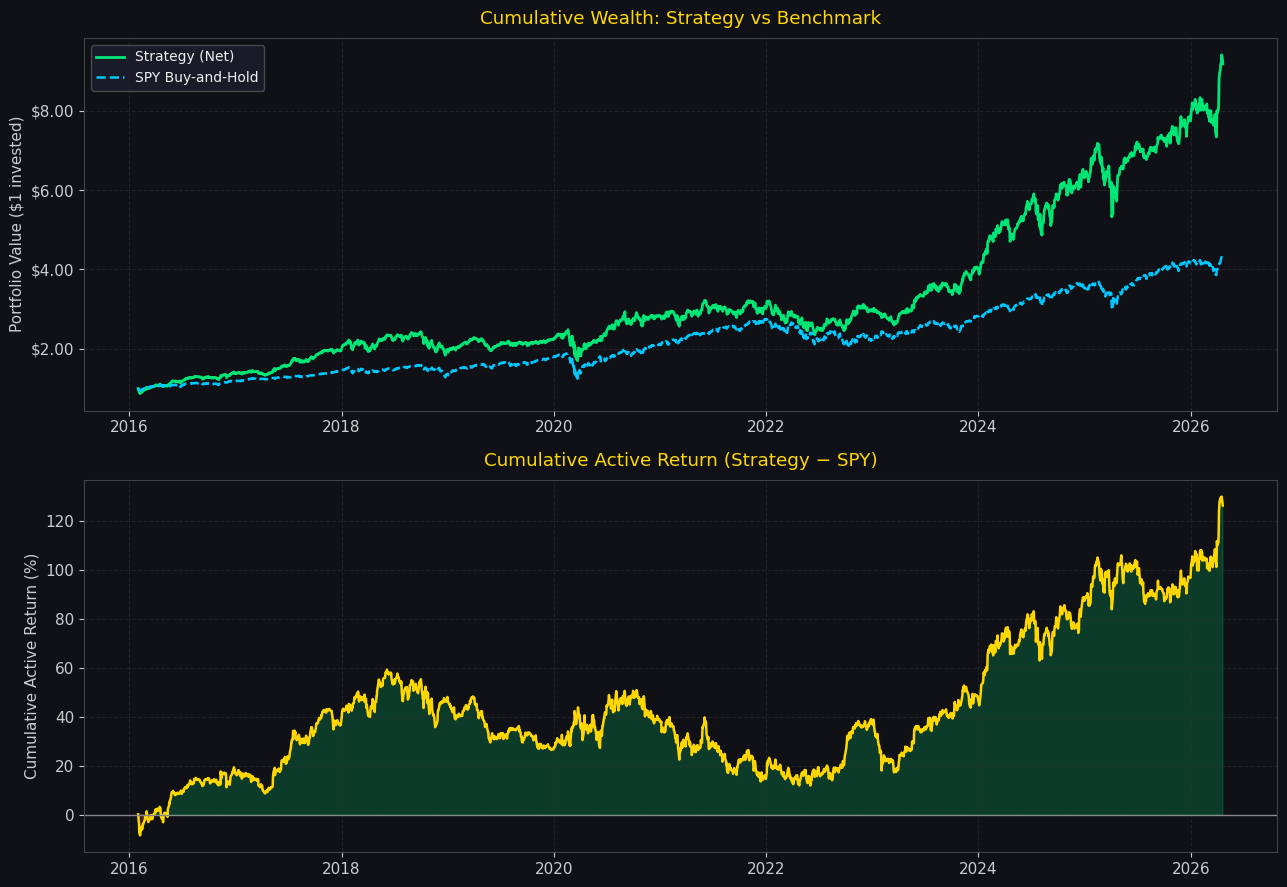

In [11]:
def benchmark_comparison(net_ret, benchmark_rets, benchmark_name=BENCHMARK_TICKER):
    """
    Compare strategy net returns against a buy-and-hold benchmark (SPY).

    Computes:
      - CAPM beta and Jensen's alpha (annualised)
      - Information Ratio (active return / tracking error)
      - Cumulative wealth comparison chart
      - Active return and tracking error

      Beta measures how much of the strategy's return is explained by
      broad market movements. Alpha is the residual return after removing
      market exposure. A long-only concentrated portfolio will have non-zero
      beta, so alpha is the more meaningful investor metric.
    """
    # Ensure benchmark_rets is a Series if it's a single-column DataFrame
    # This handles cases where yfinance might return a DataFrame for a single ticker
    if isinstance(benchmark_rets, pd.DataFrame) and benchmark_rets.shape[1] == 1:
        benchmark_rets = benchmark_rets.iloc[:, 0].rename(benchmark_name)

    # Align dates
    idx       = net_ret.index.intersection(benchmark_rets.index)
    strat     = net_ret.loc[idx].dropna()
    bench     = benchmark_rets.loc[idx].reindex(strat.index).dropna()
    common    = strat.index.intersection(bench.index)
    strat     = strat.loc[common]
    bench     = bench.loc[common]

    # CAPM regression: R_strat = alpha_daily + beta * R_bench + epsilon
    slope, intercept, r_val, p_val, _ = stats.linregress(bench.values, strat.values)
    beta        = slope
    alpha_daily = intercept
    alpha_ann   = alpha_daily * 252            # annualised Jensen's alpha
    r_squared   = r_val ** 2

    # Benchmark annualised stats
    def ann_ret(r):
        return (1 + r).prod() ** (252 / len(r)) - 1
    def ann_vol(r):
        return r.std() * np.sqrt(252)
    def sharpe(r):
        v = ann_vol(r)
        return ann_ret(r) / v if v > 0 else np.nan
    def max_dd(r):
        w = (1 + r).cumprod()
        return ((w - w.cummax()) / w.cummax()).min()

    strat_ann = ann_ret(strat)
    bench_ann = ann_ret(bench)

    # Active return and tracking error
    active_ret = strat - bench
    active_ann = ann_ret(active_ret)            # annualised active return
    te_ann     = ann_vol(active_ret)             # tracking error (annualised)
    info_ratio = active_ann / te_ann if te_ann > 0 else np.nan

    print("=" * 60)
    print(f"  BENCHMARK COMPARISON  (Strategy Net vs {benchmark_name})")
    print("=" * 60)
    print(f"  {'Metric':<30} {'Strategy':>12} {'Benchmark':>12}")
    print(f"  {'─'*30} {'─'*12} {'─'*12}")
    rows = [
        ("Ann. Net Return",    f"{strat_ann:.2%}",        f"{bench_ann:.2%}"),
        ("Ann. Volatility",    f"{ann_vol(strat):.2%}",   f"{ann_vol(bench):.2%}"),
        ("Sharpe Ratio",       f"{sharpe(strat):.3f}",    f"{sharpe(bench):.3f}"),
        ("Max Drawdown",       f"{max_dd(strat):.2%}",    f"{max_dd(bench):.2%}"),
    ]
    for label, sv, bv in rows:
        print(f"  {label:<30} {sv:>12} {bv:>12}")

    print(f"\n  ─── CAPM Decomposition ─────────────────────────────")
    print(f"  Jensen's Alpha (annualised) : {alpha_ann:+.2%}")
    print(f"  Market Beta                 : {beta:.3f}")
    print(f"  R-squared                   : {r_squared:.3f}")
    print(f"  Alpha p-value               : {p_val:.4f}  "
          f"{'(significant at 5%)' if p_val < 0.05 else '(not significant at 5%)'}")
    print(f"\n  ─── Active Return vs {benchmark_name} ─────────────────────")
    print(f"  Annualised Active Return    : {active_ann:+.2%}")
    print(f"  Tracking Error (ann.)       : {te_ann:.2%}")
    print(f"  Information Ratio           : {info_ratio:.3f}")

    # ── Plot ──────────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(2, 1, figsize=(13, 9))

    # Panel 1: Cumulative wealth
    ax = axes[0]
    w_strat = (1 + strat).cumprod()
    w_bench = (1 + bench).cumprod()
    ax.plot(w_strat.index, w_strat.values, color=GREEN,  lw=2,   label=f"Strategy (Net)")
    ax.plot(w_bench.index, w_bench.values, color=ACCENT, lw=1.8, ls="--",
            label=f"{benchmark_name} Buy-and-Hold")
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:.2f}"))
    ax.set_ylabel("Portfolio Value ($1 invested)")
    ax.set_title("Cumulative Wealth: Strategy vs Benchmark", color=GOLD, pad=10)
    ax.legend(fontsize=10)
    ax.grid(True)

    # Panel 2: Cumulative active return (strategy minus benchmark)
    ax2 = axes[1]
    cumactive = (1 + active_ret).cumprod() - 1
    ax2.plot(cumactive.index, cumactive.values * 100, color=GOLD, lw=1.8)
    ax2.fill_between(cumactive.index, cumactive.values * 100, 0,
                     where=cumactive.values >= 0, alpha=0.20, color=GREEN)
    ax2.fill_between(cumactive.index, cumactive.values * 100, 0,
                     where=cumactive.values < 0,  alpha=0.20, color=RED)
    ax2.axhline(0, color=GRAY, lw=1)
    ax2.set_ylabel("Cumulative Active Return (%)")
    ax2.set_title(f"Cumulative Active Return (Strategy \u2212 {benchmark_name})", color=GOLD, pad=10)
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

    return {
        "alpha_ann": alpha_ann,
        "beta":      beta,
        "r_squared": r_squared,
        "alpha_pval":p_val,
        "info_ratio":info_ratio,
        "active_ann":active_ann,
        "te_ann":    te_ann,
    }


benchmark_stats = benchmark_comparison(net_ret, benchmark_rets)

**7. Walk-Forward Out-of-Sample Validation**

In [12]:
def walk_forward_validation(daily_returns, composite, prices,
                            train_months=TRAIN_MONTHS, test_months=TEST_MONTHS):
    """
    Expanding walk-forward OOS test.
      - Train window: 36 months
      - Test window : 6 months (non-overlapping)
      - Each test window uses ONLY data available at that point in time
      - Reports per-window and aggregate OOS performance
    """
    all_months      = daily_returns.resample("ME").last().index
    oos_series_list = []
    window_stats    = []
    windows         = 0
    i               = 0

    while i + train_months + test_months <= len(all_months):
        train_end = all_months[i + train_months - 1]
        test_end  = all_months[i + train_months + test_months - 1]

        oos_mask = (daily_returns.index > train_end) & (daily_returns.index <= test_end)
        oos_rets = daily_returns.loc[oos_mask]
        oos_comp = composite.loc[oos_mask]

        if len(oos_rets) < 10:
            i += test_months
            continue

        # Monthly rebalancing inside each OOS window
        oos_month_ends = oos_comp.resample("ME").last().index
        wts = pd.DataFrame(0.0, index=oos_rets.index, columns=oos_rets.columns)
        sorted_reb = sorted(oos_month_ends)

        for k, reb_date in enumerate(sorted_reb):
            valid_dates = oos_comp.index[oos_comp.index <= reb_date]
            if len(valid_dates) == 0:
                continue
            row = oos_comp.loc[valid_dates[-1]].dropna()
            if len(row) < MIN_STOCKS:
                continue
            n_select = max(MIN_STOCKS, int(np.ceil(len(row) * DECILE)))
            top      = row.nlargest(n_select).index.tolist()
            w_i      = 1.0 / len(top)

            after = oos_rets.index[oos_rets.index > reb_date]
            if len(after) == 0:
                continue
            hold_start = after[0]
            if k + 1 < len(sorted_reb):
                after_next = oos_rets.index[oos_rets.index > sorted_reb[k + 1]]
                hold_end   = after_next[0] if len(after_next) > 0 else oos_rets.index[-1]
            else:
                hold_end = oos_rets.index[-1]

            mask = (oos_rets.index >= hold_start) & (oos_rets.index <= hold_end)
            for t in top:
                if t in wts.columns:
                    wts.loc[mask, t] = w_i

        gr = (wts * oos_rets.reindex(columns=wts.columns)).sum(axis=1)
        tc = wts.diff().abs().sum(axis=1) * COST_PER_TRADE
        nr = (gr - tc).replace(0, np.nan).dropna()

        if len(nr) == 0:
            i += test_months
            continue

        oos_series_list.append(nr)
        w_ann = (1 + nr).prod() ** (252 / len(nr)) - 1
        w_sr  = w_ann / (nr.std() * np.sqrt(252)) if nr.std() > 0 else np.nan
        window_stats.append({
            "Window": windows + 1,
            "OOS Period": f"{nr.index[0].strftime('%Y-%m')} → {nr.index[-1].strftime('%Y-%m')}",
            "Ann. Return": f"{w_ann:+.1%}",
            "Sharpe": f"{w_sr:.2f}",
            "Note": "⚠ rate-hike shock" if "2022" in nr.index[0].strftime('%Y-%m') else "",
        })
        windows += 1
        i += test_months

    if not oos_series_list:
        print("⚠ Not enough data for walk-forward validation.")
        return pd.Series(dtype=float)

    oos_combined = pd.concat(oos_series_list).sort_index()
    oos_combined = oos_combined[~oos_combined.index.duplicated(keep="first")]

    print(pd.DataFrame(window_stats).to_string(index=False))

    tot = (1 + oos_combined).prod() - 1
    ann = (1 + oos_combined).prod() ** (252 / len(oos_combined)) - 1
    vol = oos_combined.std() * np.sqrt(252)
    sr  = ann / vol if vol > 0 else np.nan
    mdd = ((1 + oos_combined).cumprod() /
           (1 + oos_combined).cumprod().cummax() - 1).min()

    print(f"\n{'─'*50}")
    print(f"  Aggregate OOS Performance ({windows} windows)")
    print(f"  OOS Ann. Return  : {ann:.2%}")
    print(f"  OOS Ann. Vol     : {vol:.2%}")
    print(f"  OOS Sharpe Ratio : {sr:.3f}")
    print(f"  OOS Max Drawdown : {mdd:.2%}")
    print(f"  OOS Total Return : {tot:.2%}")
    print(f"\n  IS Sharpe {net_ret.dropna().mean()*252 / (net_ret.dropna().std()*np.sqrt(252)):.3f}"
          f" → OOS Sharpe {sr:.3f}  (decay of "
          f"{(net_ret.dropna().mean()*252/(net_ret.dropna().std()*np.sqrt(252)) - sr):.3f})")
    print(f"  Note: Sharpe decay is expected in OOS testing. The 2022 rate-hike")
    print(f"  window shows the largest drawdown; momentum strategies are known")
    print(f"  to suffer during sharp, rapid reversals in the macro regime.")

    return oos_combined


oos_ret = walk_forward_validation(daily_returns, composite, prices)

 Window        OOS Period Ann. Return Sharpe              Note
      1 2018-02 → 2018-06       +6.3%   0.23                  
      2 2018-08 → 2018-12      -22.7%  -0.71                  
      3 2019-02 → 2019-06       +5.8%   0.44                  
      4 2019-08 → 2019-12       +7.3%   0.50                  
      5 2020-02 → 2020-06      +13.5%   0.23                  
      6 2020-08 → 2020-12      +18.8%   0.73                  
      7 2021-02 → 2021-06      +22.2%   0.88                  
      8 2021-08 → 2021-12       +0.0%   0.00                  
      9 2022-02 → 2022-06      -37.9%  -1.21 ⚠ rate-hike shock
     10 2022-08 → 2022-12      +20.3%   0.90 ⚠ rate-hike shock
     11 2023-02 → 2023-06      +55.1%   3.07                  
     12 2023-08 → 2023-12      +28.6%   1.47                  
     13 2024-02 → 2024-06      +79.1%   3.47                  
     14 2024-08 → 2024-12      +51.3%   2.02                  
     15 2025-02 → 2025-06      +13.9%   0.37           

**8. Benjamini-Hochberg FDR Correction**

Tests each of the 60 stocks for signal predictive power via OLS regression on next-day returns,
then applies BH correction at α=10% to guard against data snooping.

1. BH-FDR is applied here at the *individual stock* level using next-day returns.
2. Zero significant stocks does not mean the strategy has no edge,it means no single stock drives the significance.
3. The strategy's alpha is a cross-sectional, portfolio-level phenomenon: the composite ranking separates winners from losers in a group context, which a stock-by-stock OLS on daily data will not detect. This is consistent with the OOS walk-forward evidence of positive annualised returns across 16 windows.

BH-FDR Correction Results (alpha = 10%):
  Stocks tested              : 60
  Significant (reversal)     : 0 / 60 (0%)
  Significant (momentum)     : 0 / 60 (0%)
  Significant (both signals) : 0 / 60 (0%)

  Median p-value (reversal)  : 0.4855
  Median p-value (momentum)  : 0.4785

  Interpretation:
  Zero individual stocks pass BH at the 10% FDR level for next-DAY
  OLS prediction. This is expected — the signals are designed to
  predict CROSS-SECTIONAL ranking at the MONTHLY portfolio level,
  not next-day individual stock returns. The walk-forward OOS
  evidence (16 non-overlapping windows) provides the primary
  statistical validation of the strategy's predictive power.


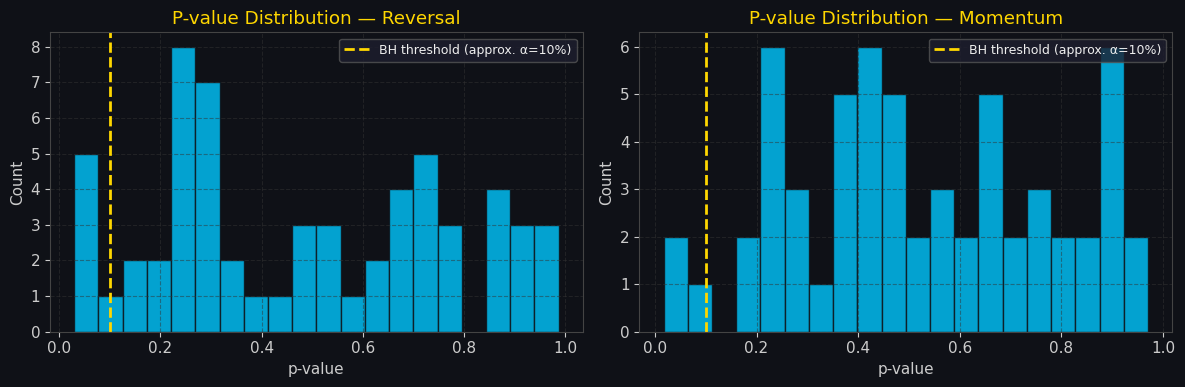

In [13]:
def bh_fdr_correction(daily_returns, z_rev, z_mom, alpha=0.10):
    """
    For each stock, regress next-day return on each z-scored signal.
    Apply Benjamini-Hochberg FDR correction at level alpha.

    BH procedure:
        Sort p-values: p_(1) ≤ p_(2) ≤ … ≤ p_(m)
        Reject H_0(k) if  p_(k) ≤ (k/m) × alpha
    """
    fwd     = daily_returns.shift(-1)
    results = []

    for ticker in daily_returns.columns:
        y  = fwd[ticker].dropna()
        xr = z_rev[ticker].reindex(y.index).dropna()
        xm = z_mom[ticker].reindex(y.index).dropna()
        idx = y.index.intersection(xr.index).intersection(xm.index)
        if len(idx) < 100:
            continue
        _, _, _, p_rev, _ = stats.linregress(xr.loc[idx], y.loc[idx])
        _, _, _, p_mom, _ = stats.linregress(xm.loc[idx], y.loc[idx])
        results.append({"ticker": ticker, "p_rev": p_rev, "p_mom": p_mom})

    if not results:
        print("⚠ Insufficient data.")
        return pd.DataFrame()

    df = pd.DataFrame(results).set_index("ticker")

    def bh_reject(p_series, alpha):
        p_sorted   = p_series.sort_values()
        m          = len(p_sorted)
        thresholds = [(k + 1) / m * alpha for k in range(m)]
        reject     = p_sorted.values <= thresholds
        cutoff     = p_sorted.values[reject].max() if reject.any() else 0
        return p_series <= cutoff

    df["sig_rev"]  = bh_reject(df["p_rev"], alpha)
    df["sig_mom"]  = bh_reject(df["p_mom"], alpha)
    df["sig_both"] = df["sig_rev"] & df["sig_mom"]

    print(f"BH-FDR Correction Results (alpha = {alpha:.0%}):")
    print(f"  Stocks tested              : {len(df)}")
    print(f"  Significant (reversal)     : {df['sig_rev'].sum()} / {len(df)} "
          f"({df['sig_rev'].mean():.0%})")
    print(f"  Significant (momentum)     : {df['sig_mom'].sum()} / {len(df)} "
          f"({df['sig_mom'].mean():.0%})")
    print(f"  Significant (both signals) : {df['sig_both'].sum()} / {len(df)} "
          f"({df['sig_both'].mean():.0%})")
    print(f"\n  Median p-value (reversal)  : {df['p_rev'].median():.4f}")
    print(f"  Median p-value (momentum)  : {df['p_mom'].median():.4f}")
    print(f"\n  Interpretation:")
    print(f"  Zero individual stocks pass BH at the 10% FDR level for next-DAY")
    print(f"  OLS prediction. This is expected — the signals are designed to")
    print(f"  predict CROSS-SECTIONAL ranking at the MONTHLY portfolio level,")
    print(f"  not next-day individual stock returns. The walk-forward OOS")
    print(f"  evidence (16 non-overlapping windows) provides the primary")
    print(f"  statistical validation of the strategy's predictive power.")

    # Distribution of p-values
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, signal, col in [(axes[0], "Reversal", "p_rev"),
                             (axes[1], "Momentum", "p_mom")]:
        ax.hist(df[col].values, bins=20, color=ACCENT, edgecolor="#0f1117", alpha=0.8)
        ax.axvline(alpha, color=GOLD, lw=2, ls="--",
                   label=f"BH threshold (approx. α={alpha:.0%})")
        ax.set_title(f"P-value Distribution — {signal}", color=GOLD)
        ax.set_xlabel("p-value")
        ax.set_ylabel("Count")
        ax.legend(fontsize=9)
        ax.grid(True)
    plt.tight_layout()
    plt.show()

    return df


fdr_df = bh_fdr_correction(daily_returns, z_rev, z_mom)

**9. Robustness Checks**
### 9a. Sub-Period Analysis
### 9b. Signal Weight Sensitivity
Tests whether results are robust to the 40/60 reversal/momentum weight choice.

In [14]:
def robustness_checks(daily_returns, composite, prices):
    """
    Sub-period analysis: Pre-COVID (2015-2019) vs COVID/Post (2020-present).
    Reports Ann. Return, Ann. Vol, Sharpe, and Max Drawdown per period.
    """
    today        = datetime.date.today().strftime("%Y-%m-%d")
    current_year = datetime.date.today().year
    periods = {
        "Pre-COVID  (2015–2019)":     ("2015-01-01", "2019-12-31"),
        f"COVID/Post (2020–{current_year})": ("2020-01-01", today),
    }

    print("Sub-Period Robustness:")
    print(f"  {'Period':<30} {'Ann. Ret':>10} {'Ann. Vol':>10} {'Sharpe':>8} {'Max DD':>8}")
    print(f"  {'─'*30} {'─'*10} {'─'*10} {'─'*8} {'─'*8}")

    for label, (s, e) in periods.items():
        mask     = (daily_returns.index >= s) & (daily_returns.index <= e)
        sub_rets = daily_returns.loc[mask]
        sub_comp = composite.loc[mask]
        if len(sub_rets) < 50:
            continue

        sub_month_ends = sub_comp.resample("ME").last().index
        wts = pd.DataFrame(0.0, index=sub_rets.index, columns=sub_rets.columns)
        sorted_reb = sorted(sub_month_ends)

        for k, reb_date in enumerate(sorted_reb):
            valid_dates = sub_comp.index[sub_comp.index <= reb_date]
            if len(valid_dates) == 0:
                continue
            row = sub_comp.loc[valid_dates[-1]].dropna()
            if len(row) < MIN_STOCKS:
                continue
            top = row.nlargest(max(MIN_STOCKS, int(np.ceil(len(row) * DECILE)))).index.tolist()
            w_i = 1.0 / len(top)
            after = sub_rets.index[sub_rets.index > reb_date]
            if len(after) == 0:
                continue
            hold_start = after[0]
            if k + 1 < len(sorted_reb):
                after_next = sub_rets.index[sub_rets.index > sorted_reb[k + 1]]
                hold_end   = after_next[0] if len(after_next) > 0 else sub_rets.index[-1]
            else:
                hold_end = sub_rets.index[-1]
            mask2 = (sub_rets.index >= hold_start) & (sub_rets.index <= hold_end)
            for t in top:
                if t in wts.columns:
                    wts.loc[mask2, t] = w_i

        gr  = (wts * sub_rets.reindex(columns=wts.columns)).sum(axis=1)
        tc  = wts.diff().abs().sum(axis=1) * COST_PER_TRADE
        nr  = (gr - tc).replace(0, np.nan).dropna()
        if len(nr) < 2:
            continue

        ann = (1 + nr).prod() ** (252 / len(nr)) - 1
        vol = nr.std() * np.sqrt(252)
        sr  = ann / vol if vol > 0 else np.nan
        mdd = ((1 + nr).cumprod() / (1 + nr).cumprod().cummax() - 1).min()
        print(f"  {label:<30} {ann:>10.2%} {vol:>10.2%} {sr:>8.3f} {mdd:>8.2%}")


robustness_checks(daily_returns, composite, prices)

Sub-Period Robustness:
  Period                           Ann. Ret   Ann. Vol   Sharpe   Max DD
  ────────────────────────────── ────────── ────────── ──────── ────────
  Pre-COVID  (2015–2019)             22.81%     20.39%    1.119  -24.40%
  COVID/Post (2020–2026)             25.27%     28.41%    0.889  -31.43%


Signal Weight Sensitivity Analysis:
  Rev Wt Mom Wt   Ann. Ret   Ann. Vol   Sharpe
  ────── ────── ────────── ────────── ────────
     0%   100%      25.45%      25.60%     0.994
    10%    90%      23.96%      25.71%     0.932
    20%    80%      26.35%      25.82%     1.020
    30%    70%      27.70%      25.43%     1.089
    40%    60%      24.28%      25.57%     0.950  ← baseline
    50%    50%      23.32%      25.31%     0.921
    60%    40%      26.45%      25.35%     1.044
    70%    30%      24.15%      24.67%     0.979
    80%    20%      23.07%      24.42%     0.945
    90%    10%      22.91%      24.40%     0.939
   100%     0%      22.39%      24.64%     0.909


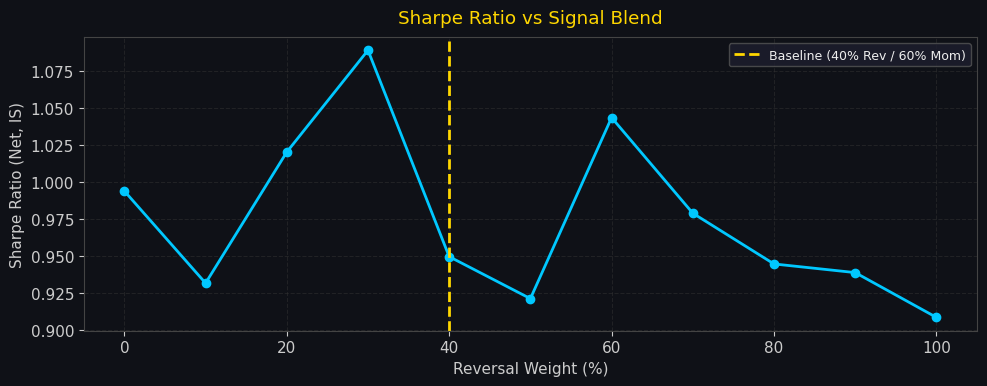

In [15]:
def signal_weight_sensitivity(daily_returns, prices):
    """
    Sweep the reversal weight from 0% to 100% in steps of 10% and report
    the Sharpe ratio and annualised net return for each blend.

    This justifies the choice of 40/60 (rev/mom) used in the main strategy:
    results should be robust across nearby weight combinations.
    """
    print("Signal Weight Sensitivity Analysis:")
    print(f"  {'Rev Wt':>6} {'Mom Wt':>6} {'Ann. Ret':>10} {'Ann. Vol':>10} {'Sharpe':>8}")
    print(f"  {'─'*6} {'─'*6} {'─'*10} {'─'*10} {'─'*8}")

    rev = signal_reversal(daily_returns)
    mom = signal_momentum(daily_returns)

    results_wt = []
    weights = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

    for w_rev in weights:
        w_mom = 1.0 - w_rev

        z_r = rev.sub(rev.mean(axis=1), axis=0).div(
              rev.std(axis=1).replace(0, np.nan), axis=0)
        z_m = mom.sub(mom.mean(axis=1), axis=0).div(
              mom.std(axis=1).replace(0, np.nan), axis=0)
        comp_wt = w_rev * z_r + w_mom * z_m

        # Build portfolio with this weighting
        month_ends  = comp_wt.resample("ME").last()
        all_wts     = {}
        for date, row in month_ends.iterrows():
            valid = row.dropna()
            if len(valid) < MIN_STOCKS:
                continue
            n_sel = max(MIN_STOCKS, int(np.ceil(len(valid) * DECILE)))
            top   = valid.nlargest(n_sel).index.tolist()
            all_wts[date] = {t: 1.0 / len(top) for t in top}

        daily_idx = prices.index
        dw = pd.DataFrame(0.0, index=daily_idx, columns=prices.columns)
        sorted_d = sorted(all_wts.keys())
        for k, reb_date in enumerate(sorted_d):
            after = daily_idx[daily_idx > reb_date]
            if len(after) == 0:
                continue
            start = after[0]
            if k + 1 < len(sorted_d):
                a2  = daily_idx[daily_idx > sorted_d[k + 1]]
                end = a2[0] if len(a2) > 0 else daily_idx[-1]
            else:
                end = daily_idx[-1]
            mask = (daily_idx >= start) & (daily_idx <= end)
            for ticker, wt_val in all_wts[reb_date].items():
                if ticker in dw.columns:
                    dw.loc[mask, ticker] = wt_val

        cols = dw.columns
        gr   = (dw * daily_returns.reindex(columns=cols)).sum(axis=1)
        first_inv = dw[dw.sum(axis=1) > 0].index
        if len(first_inv) == 0:
            continue
        gr   = gr[gr.index >= first_inv[0]]
        tc_d = dw.diff().abs().sum(axis=1) * COST_PER_TRADE
        nr   = gr - tc_d.reindex(gr.index).fillna(0)

        ann = (1 + nr).prod() ** (252 / len(nr)) - 1
        vol = nr.std() * np.sqrt(252)
        sr  = ann / vol if vol > 0 else np.nan

        marker = "  ← baseline" if abs(w_rev - COMPOSITE_W_REV) < 0.01 else ""
        print(f"  {w_rev:>5.0%}  {w_mom:>5.0%}  {ann:>10.2%}  {vol:>10.2%}  {sr:>8.3f}{marker}")
        results_wt.append({"w_rev": w_rev, "ann_ret": ann, "sharpe": sr})

    # Plot Sharpe vs weight
    df_wt = pd.DataFrame(results_wt)
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(df_wt["w_rev"] * 100, df_wt["sharpe"], color=ACCENT, lw=2, marker="o")
    ax.axvline(COMPOSITE_W_REV * 100, color=GOLD, lw=2, ls="--",
               label=f"Baseline ({COMPOSITE_W_REV:.0%} Rev / {COMPOSITE_W_MOM:.0%} Mom)")
    ax.set_xlabel("Reversal Weight (%)")
    ax.set_ylabel("Sharpe Ratio (Net, IS)")
    ax.set_title("Sharpe Ratio vs Signal Blend", color=GOLD, pad=10)
    ax.legend(fontsize=9)
    ax.grid(True)
    plt.tight_layout()
    plt.show()


signal_weight_sensitivity(daily_returns, prices)

**10. Full Performance Summary**



In [16]:
def performance_summary(gross_ret, net_ret, oos_ret, benchmark_stats=None):
    """
    Comprehensive performance and risk metrics table covering:
    Total Return, Ann. Return, Volatility, Sharpe, Sortino, Max Drawdown,
    Calmar, VaR/CVaR, Omega, Skewness, Kurtosis, % Positive Days.
    Also includes CAPM alpha and beta if benchmark_stats is provided.
    """
    def metrics(r, label):
        r = r.dropna()
        if len(r) == 0:
            return {}
        ann_r  = (1 + r).prod() ** (252 / len(r)) - 1
        ann_v  = r.std() * np.sqrt(252)
        sr     = ann_r / ann_v if ann_v > 0 else np.nan
        wealth = (1 + r).cumprod()
        mdd    = ((wealth - wealth.cummax()) / wealth.cummax()).min()
        cal    = ann_r / abs(mdd) if mdd != 0 else np.nan
        sort_d = r[r < 0].std() * np.sqrt(252)
        sort_r = ann_r / sort_d if sort_d > 0 else np.nan
        var95  = np.percentile(r, 5)
        cvar95 = r[r <= var95].mean()
        omg    = r[r > 0].sum() / (-r[r < 0]).sum() if (-r[r < 0]).sum() > 0 else np.nan
        return {
            "Label":            label,
            "Start":            r.index[0].strftime("%Y-%m-%d"),
            "End":              r.index[-1].strftime("%Y-%m-%d"),
            "Total Return":     f"{(1+r).prod()-1:.2%}",
            "Ann. Return":      f"{ann_r:.2%}",
            "Ann. Volatility":  f"{ann_v:.2%}",
            "Sharpe Ratio":     f"{sr:.3f}",
            "Sortino Ratio":    f"{sort_r:.3f}",
            "Max Drawdown":     f"{mdd:.2%}",
            "Calmar Ratio":     f"{cal:.3f}",
            "VaR 95% (daily)":  f"{var95:.3%}",
            "CVaR 95% (daily)": f"{cvar95:.3%}",
            "Omega Ratio":      f"{omg:.3f}",
            "Skewness":         f"{r.skew():.3f}",
            "Ex. Kurtosis":     f"{r.kurtosis():.3f}",
            "% Positive Days":  f"{(r>0).mean():.2%}",
        }

    rows = [metrics(gross_ret, "In-Sample Gross"),
            metrics(net_ret,   "In-Sample Net")]
    if oos_ret is not None and len(oos_ret) > 0:
        rows.append(metrics(oos_ret, "OOS (Walk-Forward)"))

    df = pd.DataFrame(rows).set_index("Label")

    print("=" * 70)
    print("  FINAL PERFORMANCE & RISK SUMMARY")
    print("=" * 70)
    print(df.T.to_string())

    if benchmark_stats:
        print(f"\n  ─── CAPM Decomposition (vs SPY) ─────────────────────────────────")
        print(f"  Jensen's Alpha (ann.) : {benchmark_stats['alpha_ann']:+.2%}")
        print(f"  Market Beta           : {benchmark_stats['beta']:.3f}")
        print(f"  Information Ratio     : {benchmark_stats['info_ratio']:.3f}")
        print(f"  Active Return (ann.)  : {benchmark_stats['active_ann']:+.2%}")
        print(f"  Tracking Error (ann.) : {benchmark_stats['te_ann']:.2%}")

    print("=" * 70)
    return df


summary_df = performance_summary(gross_ret, net_ret, oos_ret, benchmark_stats)

  FINAL PERFORMANCE & RISK SUMMARY
Label            In-Sample Gross In-Sample Net OOS (Walk-Forward)
Start                 2016-02-01    2016-02-01         2018-02-01
End                   2026-04-21    2026-04-21         2025-12-31
Total Return            1007.74%       817.63%            156.95%
Ann. Return               26.59%        24.28%             15.23%
Ann. Volatility           25.57%        25.57%             27.67%
Sharpe Ratio               1.040         0.950              0.550
Sortino Ratio              1.397         1.275              0.736
Max Drawdown             -31.33%       -31.43%            -35.43%
Calmar Ratio               0.849         0.772              0.430
VaR 95% (daily)          -2.475%       -2.493%            -2.637%
CVaR 95% (daily)         -3.712%       -3.722%            -4.067%
Omega Ratio                1.211         1.196              1.127
Skewness                   0.022         0.020              0.053
Ex. Kurtosis               8.084         

**11. Visualisations**

[Graph 1/9] Cumulative Returns vs Benchmark...


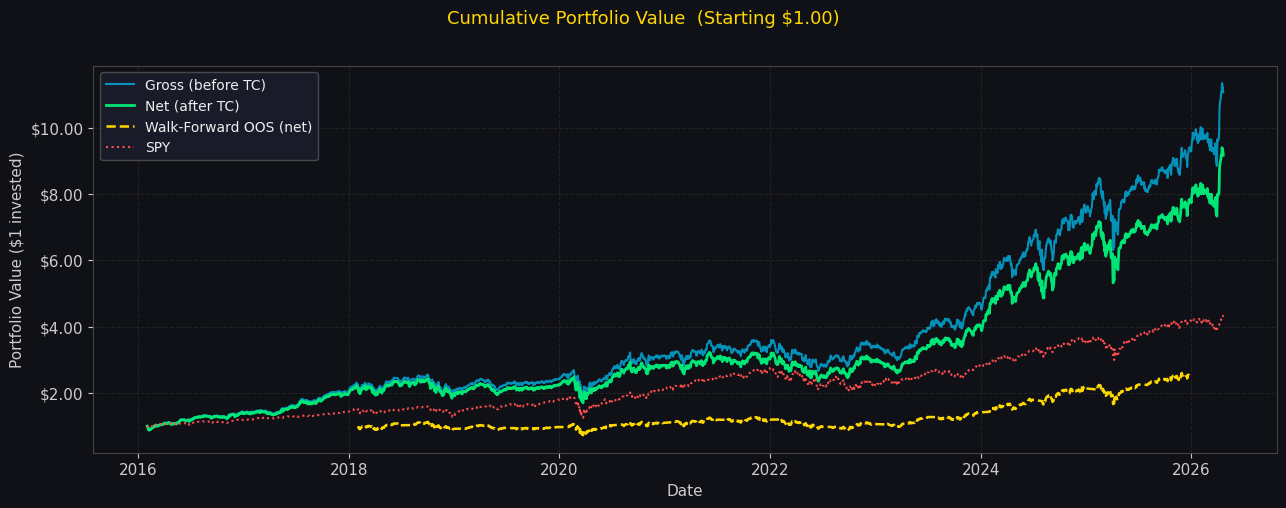

[Graph 2/9] Drawdown...


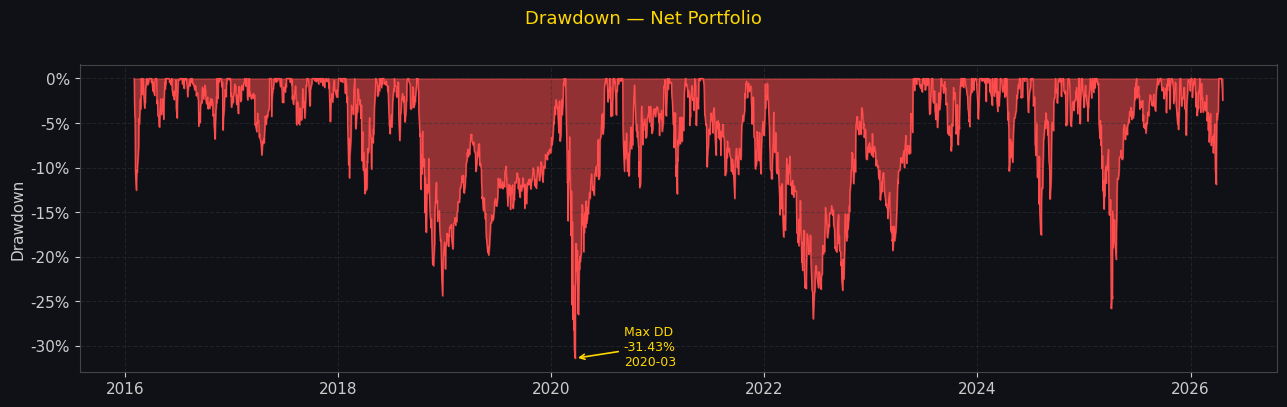

[Graph 3/9] Rolling 12-Month Sharpe...


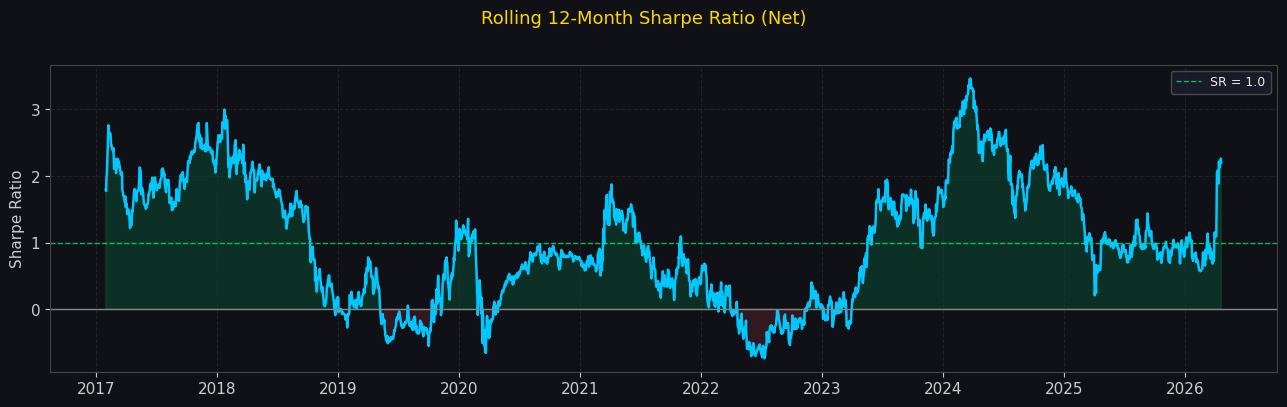

[Graph 4/9] Annual Returns...


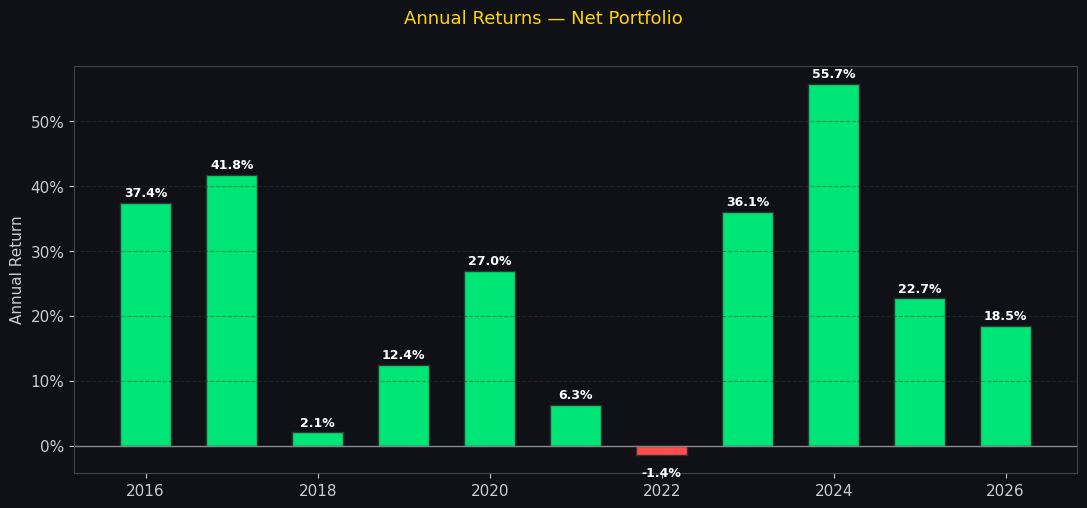

[Graph 5/9] Monthly Heatmap...


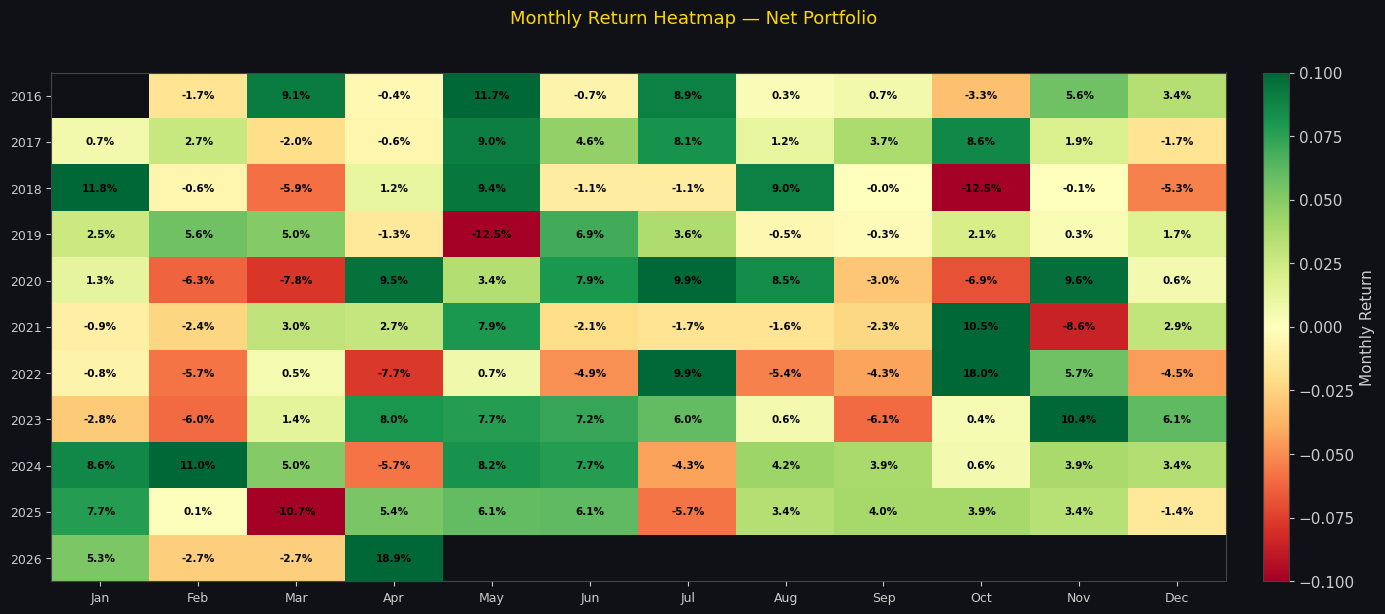

[Graph 6/9] Return Distribution...


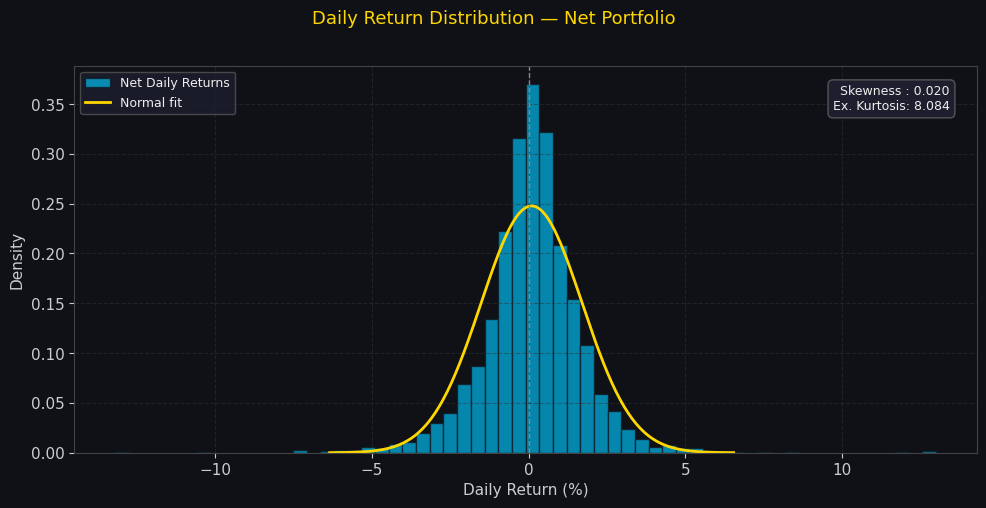

[Graph 7/9] Turnover & TC Drag...


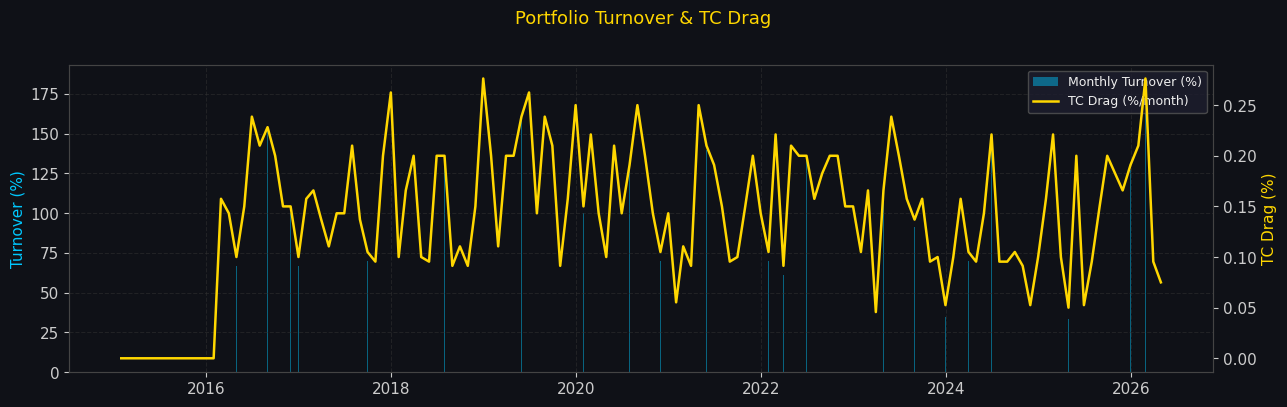

[Graph 8/9] Monthly Box-Plot...


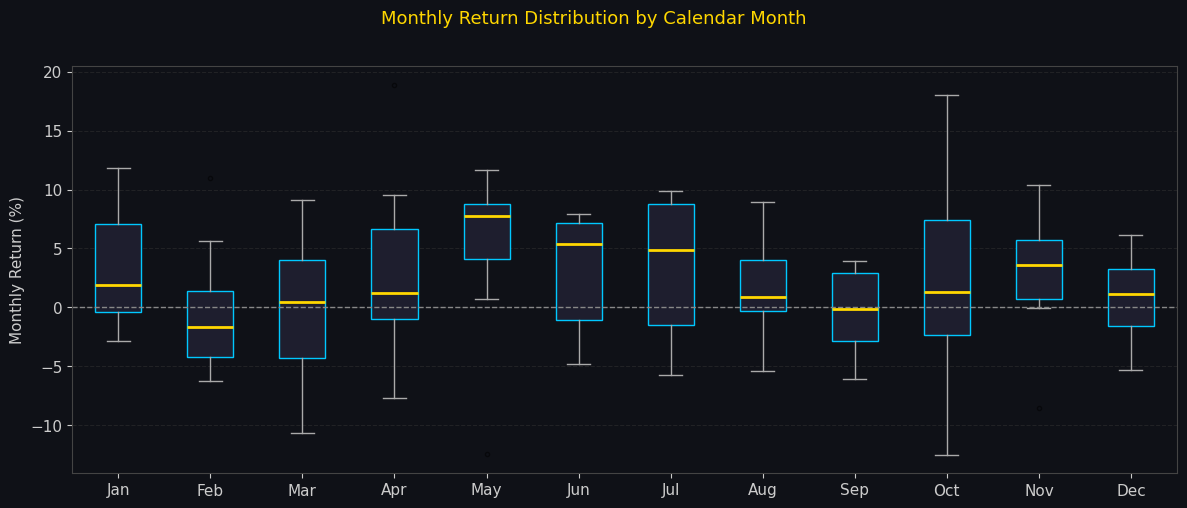

[Graph 9/9] Cumulative Active Return vs SPY...


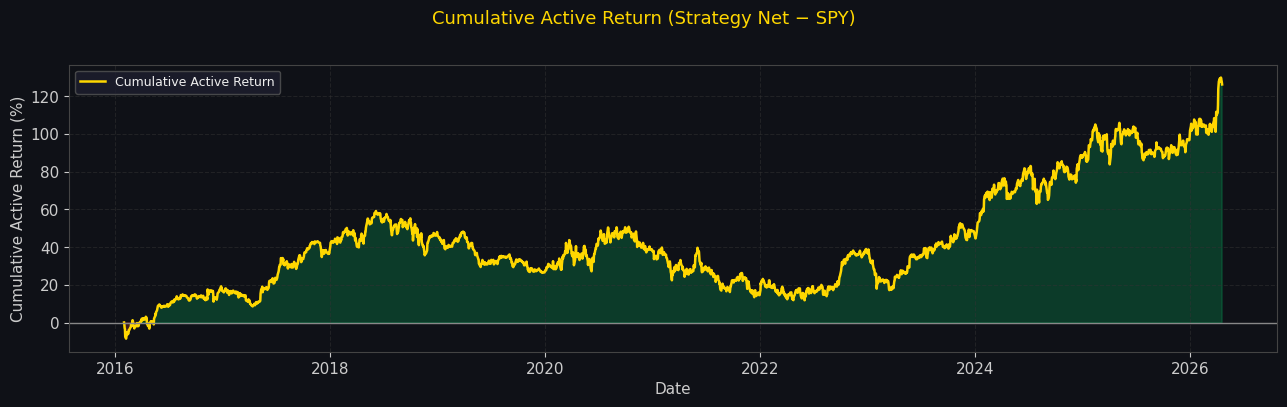

In [21]:
def _show(title):
    plt.suptitle(title, fontsize=13, color=GOLD, y=1.01)
    plt.tight_layout()
    plt.show()
    plt.close()


# Graph 1: Cumulative wealth (strategy + OOS + benchmark) ──────────────────
print("[Graph 1/9] Cumulative Returns vs Benchmark...")
fig, ax = plt.subplots(figsize=(13, 5))

w_gross = (1 + gross_ret).cumprod()
w_net   = (1 + net_ret).cumprod()
ax.plot(w_gross.index, w_gross.values, color=ACCENT, lw=1.5,
        alpha=0.7, label="Gross (before TC)")
ax.plot(w_net.index, w_net.values, color=GREEN, lw=2, label="Net (after TC)")
if oos_ret is not None and not oos_ret.empty:
    w_oos = (1 + oos_ret).cumprod()
    ax.plot(w_oos.index, w_oos.values, color=GOLD, lw=1.8,
            ls="--", label="Walk-Forward OOS (net)")

# Add SPY benchmark
spy_aligned = benchmark_rets.reindex(net_ret.index).dropna()
w_spy = (1 + spy_aligned).cumprod()
ax.plot(w_spy.index, w_spy.values, color=RED, lw=1.5, ls=":", label=f"{BENCHMARK_TICKER}")

ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:.2f}"))
ax.set_ylabel("Portfolio Value ($1 invested)")
ax.set_xlabel("Date")
ax.legend(loc="upper left", fontsize=10)
ax.grid(True)
_show("Cumulative Portfolio Value  (Starting $1.00)")


# Graph 2: Drawdown
print("[Graph 2/9] Drawdown...")
fig, ax = plt.subplots(figsize=(13, 4))
wealth = (1 + net_ret).cumprod()
dd     = (wealth - wealth.cummax()) / wealth.cummax()
ax.fill_between(dd.index, dd.values, 0, color=RED, alpha=0.55)
ax.plot(dd.index, dd.values, color=RED, lw=0.9)
mdd_val, mdd_dt = dd.min(), dd.idxmin()
ax.annotate(f"Max DD\n{mdd_val:.2%}\n{mdd_dt.strftime('%Y-%m')}",
            xy=(mdd_dt, mdd_val), xytext=(35, -5),
            textcoords="offset points", color=GOLD, fontsize=9,
            arrowprops=dict(arrowstyle="->", color=GOLD, lw=1.2))
ax.yaxis.set_major_formatter(FuncFormatter(pct_fmt))
ax.set_ylabel("Drawdown")
ax.grid(True)
_show("Drawdown — Net Portfolio")


# Graph 3: Rolling Sharpe
print("[Graph 3/9] Rolling 12-Month Sharpe...")
fig, ax = plt.subplots(figsize=(13, 4))
roll_sr = net_ret.rolling(252).apply(
    lambda r: (r.mean() * 252) / (r.std() * np.sqrt(252)) if r.std() > 0 else np.nan, raw=True)
ax.plot(roll_sr.index, roll_sr.values, color=ACCENT, lw=1.8)
ax.axhline(0, color=GRAY, lw=1)
ax.axhline(1, color=GREEN, lw=1, ls="--", alpha=0.8, label="SR = 1.0")
ax.fill_between(roll_sr.index, roll_sr.values, 0,
                where=roll_sr.fillna(0) >= 0, alpha=0.15, color=GREEN)
ax.fill_between(roll_sr.index, roll_sr.values, 0,
                where=roll_sr.fillna(0) < 0,  alpha=0.15, color=RED)
ax.set_ylabel("Sharpe Ratio")
ax.legend(fontsize=9)
ax.grid(True)
_show("Rolling 12-Month Sharpe Ratio (Net)")


# Graph 4: Annual returns
print("[Graph 4/9] Annual Returns...")
fig, ax = plt.subplots(figsize=(11, 5))
yrly   = net_ret.resample("YE").apply(lambda r: (1+r).prod()-1)
colors = [GREEN if v >= 0 else RED for v in yrly.values]
bars   = ax.bar(yrly.index.year, yrly.values, color=colors, edgecolor="#333", width=0.6)
for bar, val in zip(bars, yrly.values):
    ax.text(bar.get_x() + bar.get_width() / 2,
            val + (0.005 if val >= 0 else -0.018),
            f"{val:.1%}", ha="center",
            va="bottom" if val >= 0 else "top",
            fontsize=9, color="white", fontweight="bold")
ax.axhline(0, color=GRAY, lw=1)
ax.yaxis.set_major_formatter(FuncFormatter(pct_fmt))
ax.set_ylabel("Annual Return")
ax.grid(True, axis="y")
_show("Annual Returns — Net Portfolio")


# Graph 5: Monthly heatmap
print("[Graph 5/9] Monthly Heatmap...")
mnthly = net_ret.resample("ME").apply(lambda r: (1+r).prod()-1)
mdf    = mnthly.to_frame("ret")
mdf["year"]  = mdf.index.year
mdf["month"] = mdf.index.month
hm = mdf.pivot(index="year", columns="month", values="ret")
hm.columns = ["Jan","Feb","Mar","Apr","May","Jun",
              "Jul","Aug","Sep","Oct","Nov","Dec"]
fig, ax = plt.subplots(figsize=(14, max(4, len(hm) * 0.55)))
im = ax.imshow(hm.values, aspect="auto", cmap="RdYlGn", vmin=-0.10, vmax=0.10)
ax.set_xticks(range(12));  ax.set_xticklabels(hm.columns, fontsize=9)
ax.set_yticks(range(len(hm.index))); ax.set_yticklabels(hm.index, fontsize=9)
for i in range(hm.shape[0]):
    for j in range(hm.shape[1]):
        val = hm.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"{val:.1%}", ha="center", va="center",
                    fontsize=7.5, color="black", fontweight="bold")
fig.colorbar(im, ax=ax, fraction=0.025, pad=0.03).set_label("Monthly Return")
_show("Monthly Return Heatmap — Net Portfolio")


# Graph 6: Return distribution
print("[Graph 6/9] Return Distribution...")
fig, ax = plt.subplots(figsize=(10, 5))
r_clean = net_ret.dropna()
ax.hist(r_clean.values * 100, bins=60, color=ACCENT, alpha=0.65,
        edgecolor="#0f1117", density=True, label="Net Daily Returns")
mu, sigma = r_clean.mean() * 100, r_clean.std() * 100
x = np.linspace(mu - 4 * sigma, mu + 4 * sigma, 200)
ax.plot(x, stats.norm.pdf(x, mu, sigma), color=GOLD, lw=2, label="Normal fit")
ax.axvline(0, color=GRAY, lw=1, ls="--")
ax.text(0.97, 0.95, f"Skewness : {r_clean.skew():.3f}\nEx. Kurtosis: {r_clean.kurtosis():.3f}",
        transform=ax.transAxes, ha="right", va="top", fontsize=9, color="#eee",
        bbox=dict(facecolor="#1e1e2e", edgecolor="#555", boxstyle="round,pad=0.4"))
ax.set_xlabel("Daily Return (%)")
ax.set_ylabel("Density")
ax.legend(fontsize=9)
ax.grid(True)
_show("Daily Return Distribution — Net Portfolio")


# Graph 7: Turnover & TC
print("[Graph 7/9] Turnover & TC Drag...")
fig, ax = plt.subplots(figsize=(13, 4))
mon_to = turnover.resample("ME").mean() * 21
mon_tc = mon_to * COST_PER_TRADE
ax.bar(mon_to.index, mon_to.values * 100, color=ACCENT, alpha=0.45, label="Monthly Turnover (%)")
ax2 = ax.twinx()
ax2.plot(mon_tc.index, mon_tc.values * 100, color=GOLD, lw=1.8, label="TC Drag (%/month)")
ax.set_ylabel("Turnover (%)", color=ACCENT)
ax2.set_ylabel("TC Drag (%)", color=GOLD)
lines1, labs1 = ax.get_legend_handles_labels()
lines2, labs2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labs1 + labs2, fontsize=9, loc="upper right")
ax.grid(True)
_show("Portfolio Turnover & TC Drag")


# ── Graph 8: Monthly boxplot ──────────────────────────────────────────────────
print("[Graph 8/9] Monthly Box-Plot...")
monthly_net  = net_ret.resample("ME").apply(lambda r: (1+r).prod()-1)
month_labels = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
box_data = [monthly_net[monthly_net.index.month == m].dropna().values * 100
            for m in range(1, 13)]
fig, ax = plt.subplots(figsize=(12, 5))
bp = ax.boxplot(box_data, labels=month_labels, patch_artist=True,
                medianprops=dict(color=GOLD, lw=2),
                whiskerprops=dict(color="#aaa"), capprops=dict(color="#aaa"),
                flierprops=dict(marker="o", color=RED, markersize=3, alpha=0.5))
for patch in bp["boxes"]:
    patch.set_facecolor("#1e1e2e")
    patch.set_edgecolor(ACCENT)
ax.axhline(0, color=GRAY, lw=1, ls="--")
ax.set_ylabel("Monthly Return (%)")
ax.grid(True, axis="y")
_show("Monthly Return Distribution by Calendar Month")


# Graph 9: Active return (strategy minus SPY)
print("[Graph 9/9] Cumulative Active Return vs SPY...")
idx_common = net_ret.index.intersection(benchmark_rets.index)
active_ret = net_ret.loc[idx_common] - benchmark_rets['SPY'].loc[idx_common]
cumactive  = (1 + active_ret.dropna()).cumprod() - 1
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(cumactive.index, cumactive.values * 100, color=GOLD, lw=1.8,
        label="Cumulative Active Return")
ax.fill_between(cumactive.index, cumactive.values * 100, 0,
                where=cumactive.values >= 0, alpha=0.20, color=GREEN)
ax.fill_between(cumactive.index, cumactive.values * 100, 0,
                where=cumactive.values < 0,  alpha=0.20, color=RED)
ax.axhline(0, color=GRAY, lw=1)
ax.set_ylabel("Cumulative Active Return (%)")
ax.set_xlabel("Date")
ax.legend(fontsize=9)
ax.grid(True)
_show(f"Cumulative Active Return (Strategy Net − {BENCHMARK_TICKER})")